# MÉTODOS LEXICAIS (SentiLex)
## Análise de sentimentos usando léxico de sentimentos em português

**Objetivo:**
1. Usar texto com lematização (do Notebook 3)
2. Aplicar SentiLex (léxico PT-BR)
3. Testar 4 variações de métodos lexicais
4. Comparar com baseline

## 1. IMPORTAÇÕES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas!")

✅ Bibliotecas importadas!


## 2. DOWNLOAD DO SENTILEX

In [2]:
import os

# Caminho do arquivo LEMATIZADO
sentilex_path = '../data/lexicons/SentiLex-lem-PT02.txt'

print(f"📂 Carregando SentiLex Lematizado...")

if os.path.exists(sentilex_path):
    print("✅ Arquivo encontrado!")
    with open(sentilex_path, 'r', encoding='utf-8') as f:
        sentilex_data = f.read().split('\n')
else:
    print(f"❌ Arquivo não encontrado em: {sentilex_path}")
    print("💡 Certifique-se de que o arquivo está na pasta ../data/lexicons/")
    raise FileNotFoundError(f"Coloque o arquivo SentiLex-lem-PT02.txt em {sentilex_path}")

print(f"📊 Total de linhas carregadas: {len(sentilex_data):,}")

sentilex = {}
for line in sentilex_data:
    if line.strip() and not line.startswith('#'):
        parts = line.split(';')
        if len(parts) >= 2:
            palavra = parts[0].split('.')[0].lower()
            polaridade_str = [p for p in parts if 'POL' in p]
            if polaridade_str:
                try:
                    polaridade = int(polaridade_str[0].split(':')[1].split('=')[1])
                    sentilex[palavra] = polaridade
                except:
                    pass

print(f"✅ SentiLex carregado: {len(sentilex):,} palavras")

📂 Carregando SentiLex Lematizado...
✅ Arquivo encontrado!
📊 Total de linhas carregadas: 7,014
✅ SentiLex carregado: 7,010 palavras


## 3. CARREGAR DADOS

In [3]:
df = pd.read_csv('../data/processed/reviews_pln.csv')
df['label'] = df['sentimento'].map({'Positivo': 2, 'Neutro': 1, 'Negativo': 0})
print(f"Dataset: {len(df):,} reviews")

Dataset: 3,789 reviews


## 4. MÉTODOS LEXICAIS

In [5]:
# Método 1: Puro
def sentilex_puro(texto):
    score = sum([sentilex.get(p, 0) for p in str(texto).split()])
    return 2 if score > 0 else (0 if score < 0 else 1)

# Método 2: Negação
def sentilex_negacao(texto):
    palavras = str(texto).split()
    score = 0
    negacao = False
    palavras_negacao = {'não', 'nunca', 'jamais', 'nada', 'nem'}
    for p in palavras:
        if p in palavras_negacao:
            negacao = True
        else:
            pol = sentilex.get(p, 0)
            score += (-pol if negacao else pol)
            negacao = False
    return 2 if score > 0 else (0 if score < 0 else 1)

# Método 3: Intensificadores
def sentilex_intensificadores(texto):
    palavras = str(texto).split()
    score = 0
    mult = 1.0
    intensif = {'muito': 1.5, 'bem': 1.3, 'pouco': 0.5}
    for p in palavras:
        if p in intensif:
            mult = intensif[p]
        else:
            score += sentilex.get(p, 0) * mult
            mult = 1.0
    return 2 if score > 0 else (0 if score < 0 else 1)

# Método 4: Híbrido
def sentilex_hibrido(texto):
    palavras = str(texto).split()
    score = 0
    negacao = False
    mult = 1.0
    palavras_negacao = {'não', 'nunca', 'jamais'}
    intensif = {'muito': 1.5, 'bem': 1.3, 'pouco': 0.5}
    for p in palavras:
        if p in palavras_negacao:
            negacao = True
        elif p in intensif:
            mult = intensif[p]
        else:
            pol = sentilex.get(p, 0) * mult
            score += (-pol if negacao else pol)
            negacao = False
            mult = 1.0
    return 2 if score > 0 else (0 if score < 0 else 1)

In [6]:
# Aplicar métodos
print("🔄 Aplicando métodos lexicais...")
df['pred_puro'] = df['texto_lemmatized'].apply(sentilex_puro)
df['pred_negacao'] = df['texto_lemmatized'].apply(sentilex_negacao)
df['pred_intensif'] = df['texto_lemmatized'].apply(sentilex_intensificadores)
df['pred_hibrido'] = df['texto_lemmatized'].apply(sentilex_hibrido)
print("✅ Concluído!")

🔄 Aplicando métodos lexicais...
✅ Concluído!


## 5. AVALIAÇÃO

In [7]:
metodos = ['pred_puro', 'pred_negacao', 'pred_intensif', 'pred_hibrido']
nomes = ['SentiLex Puro', 'Com Negação', 'Com Intensificadores', 'Híbrido']

resultados = []
for metodo, nome in zip(metodos, nomes):
    acc = accuracy_score(df['label'], df[metodo])
    prec, rec, f1, _ = precision_recall_fscore_support(df['label'], df[metodo], average='weighted')
    resultados.append({'Método': nome, 'Acurácia': acc, 'Precisão': prec, 'Recall': rec, 'F1-Score': f1})

df_res = pd.DataFrame(resultados)
print("="*80)
print("📊 RESULTADOS - MÉTODOS LEXICAIS")
print("="*80)
display(df_res.sort_values('F1-Score', ascending=False))

# Salvar
os.makedirs('../results/metrics', exist_ok=True)
df_res.to_csv('../results/metrics/05_metricas_lexicais.csv', index=False)
print("\n💾 Métricas salvas!")

📊 RESULTADOS - MÉTODOS LEXICAIS


,Método,Acurácia,Precisão,Recall,F1-Score
0,SentiLex Puro,0.437846,0.488585,0.437846,0.441308
1,Com Negação,0.437846,0.488585,0.437846,0.441308
2,Com Intensificadores,0.437846,0.488585,0.437846,0.441308
3,Híbrido,0.437846,0.488585,0.437846,0.441308



💾 Métricas salvas!


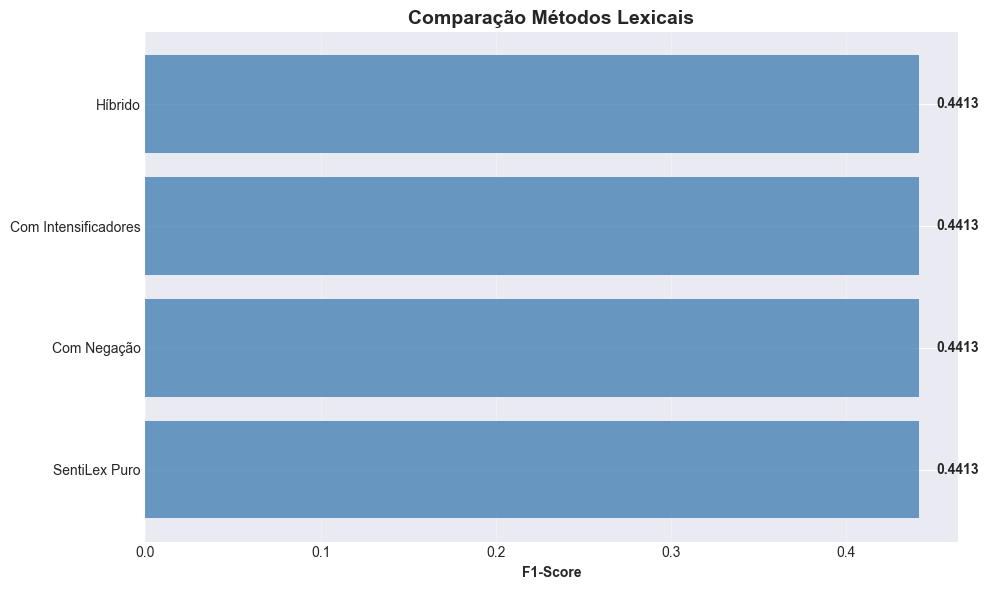

💾 Gráfico salvo!


In [8]:
# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df_res.sort_values('F1-Score', ascending=True)
ax.barh(df_plot['Método'], df_plot['F1-Score'], alpha=0.8, color='steelblue')
ax.set_xlabel('F1-Score', fontweight='bold')
ax.set_title('Comparação Métodos Lexicais', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_plot['F1-Score']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/05_comparacao_lexical.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Gráfico salvo!")

## 6. RESUMO

In [9]:
print("="*80)
print("📋 RESUMO NOTEBOOK 5")
print("="*80)
print(f"✅ 4 métodos lexicais testados")
print(f"✅ Melhor: {df_res.iloc[0]['Método']} (F1: {df_res.iloc[0]['F1-Score']:.4f})")
print(f"\n📁 Arquivos:")
print(f"   • ../results/metrics/05_metricas_lexicais.csv")
print(f"   • ../results/figures/05_comparacao_lexical.png")
print(f"\n➡️  Próximo: Notebook 6 - BERT Embeddings")

📋 RESUMO NOTEBOOK 5
✅ 4 métodos lexicais testados
✅ Melhor: SentiLex Puro (F1: 0.4413)

📁 Arquivos:
   • ../results/metrics/05_metricas_lexicais.csv
   • ../results/figures/05_comparacao_lexical.png

➡️  Próximo: Notebook 6 - BERT Embeddings
